# Volatility Regime Modeling Pipeline

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)

import pandas as pd

ROOT: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling


Configurations

In [2]:
RUN_INGESTION = False  # set True if you want to refetch/clean/merge in notebook

START_DATE = "2018-01-01"
ASSET_TICKERS = ["SPY", "QQQ", "AAPL"]
VIX_TICKERS = ["^VIX"]

RAW_DIR = ROOT / "data" / "raw"
CLEAN_DIR = ROOT / "data" / "clean"
INTERIM_DIR = ROOT / "data" / "interim"
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports" / "baselines"

RAW_ASSETS_PATH = RAW_DIR / "ohlcv_SPY-QQQ-AAPL_2018-01-01_latest_1d.parquet"
RAW_VIX_PATH = RAW_DIR / "vix_VIX_2018-01-01_latest_1d.parquet"

CLEAN_ASSETS_PATH = CLEAN_DIR / "assets_clean.parquet"
CLEAN_VIX_PATH = CLEAN_DIR / "vix_clean.parquet"

MERGED_PATH = INTERIM_DIR / "ohlcv_with_vix.parquet"
FEATURES_PATH = PROCESSED_DIR / "vol_features_5d.parquet"

HORIZON_DAYS = 5
TRAIN_END = "2022-12-30"
VAL_START = "2023-01-03"
VAL_END = "2023-12-29"
TEST_START = "2024-01-02"
N_REGIMES = 3

Data Ingestion

In [3]:
from src.pipeline.ingest import FetchSpec, fetch_ohlcv, clean_ohlcv, merge_assets_with_vix

if RUN_INGESTION:
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    CLEAN_DIR.mkdir(parents=True, exist_ok=True)
    INTERIM_DIR.mkdir(parents=True, exist_ok=True)

    # Fetch raw
    assets_raw = fetch_ohlcv(FetchSpec(tickers=ASSET_TICKERS, start=START_DATE))
    vix_raw = fetch_ohlcv(FetchSpec(tickers=VIX_TICKERS, start=START_DATE))

    assets_raw.to_parquet(RAW_ASSETS_PATH, index=False)
    vix_raw.to_parquet(RAW_VIX_PATH, index=False)

    # Clean
    assets_clean = clean_ohlcv(assets_raw)
    vix_clean = clean_ohlcv(vix_raw)

    assets_clean.to_parquet(CLEAN_ASSETS_PATH, index=False)
    vix_clean.to_parquet(CLEAN_VIX_PATH, index=False)

    # Merge
    merged = merge_assets_with_vix(assets_clean, vix_clean)
    merged.to_parquet(MERGED_PATH, index=False)

    print("Ingestion complete:", MERGED_PATH)

else:
    print("Skipping ingestion. Expecting merged file at:", MERGED_PATH)

Skipping ingestion. Expecting merged file at: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling/data/interim/ohlcv_with_vix.parquet


Reading Data

In [4]:
df = pd.read_parquet(MERGED_PATH)
df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
print("Tickers:", sorted(df["ticker"].astype(str).unique()))
df.head()

Shape: (6123, 13)
Date range: 2018-01-02 → 2026-02-13
Tickers: ['AAPL', 'QQQ', 'SPY']


,date,ticker,open,high,low,close,adj_close,volume,vix_close,vix_volume,vix_log_return,vix_rv_10,vix_rv_20
0,2018-01-02,AAPL,42.540001,43.075001,42.314999,43.064999,40.304176,102223600,9.77,0,NaN,NaN,NaN
1,2018-01-03,AAPL,43.132500,43.637501,42.990002,43.057499,40.297157,118071600,9.15,0,-0.065563,NaN,NaN
2,2018-01-04,AAPL,43.134998,43.367500,43.020000,43.257500,40.484325,89738400,9.22,0,0.007621,NaN,NaN
3,2018-01-05,AAPL,43.360001,43.842499,43.262501,43.750000,40.945263,94640000,9.22,0,0.000000,NaN,NaN
4,2018-01-08,AAPL,43.587502,43.902500,43.482498,43.587502,40.793182,82271200,9.52,0,0.032020,NaN,NaN


Feature Engineering

In [5]:
from src.pipeline.features import build_features_and_labels

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

feat = build_features_and_labels(
    merged_df=df,
    horizon_days=HORIZON_DAYS,
    train_end=TRAIN_END,
    n_regimes=N_REGIMES,
)

feat.to_parquet(FEATURES_PATH, index=False)

print("Saved features:", FEATURES_PATH)
print("Shape:", feat.shape)
feat[["date", "ticker", "regime", f"fwd_rv_{HORIZON_DAYS}"]].head()

Saved features: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling/data/processed/vol_features_5d.parquet
Shape: (5928, 30)


,date,ticker,regime,fwd_rv_5
0,2018-03-29,AAPL,2,0.277560
1,2018-04-02,AAPL,2,0.274886
2,2018-04-03,AAPL,2,0.292819
3,2018-04-04,AAPL,2,0.272819
4,2018-04-05,AAPL,2,0.277536


In [6]:
display(feat["regime"].value_counts().sort_index())
display(feat.groupby("ticker")["regime"].value_counts().sort_index())

regime
0    2241
1    2137
2    1550
Name: count, dtype: int64

ticker  regime
AAPL    0          433
        1          743
        2          800
QQQ     0          691
        1          771
        2          514
SPY     0         1117
        1          623
        2          236
Name: count, dtype: int64

Regime Distribution Over Time

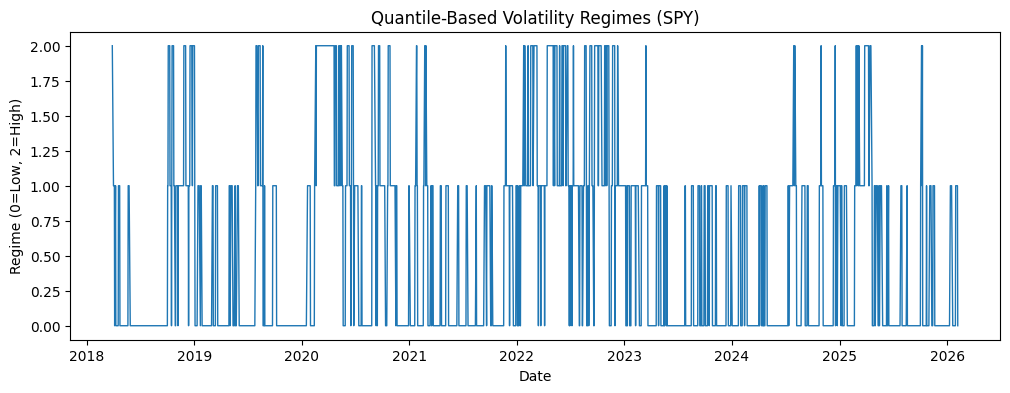

In [18]:
import matplotlib.pyplot as plt

spy = feat[feat["ticker"] == "SPY"].copy()
spy = spy.sort_values("date")

plt.figure(figsize=(12,4))
plt.plot(spy["date"], spy["regime"], linewidth=1)
plt.title("Quantile-Based Volatility Regimes (SPY)")
plt.ylabel("Regime (0=Low, 2=High)")
plt.xlabel("Date")
plt.show()

Forward Volatility Distribution

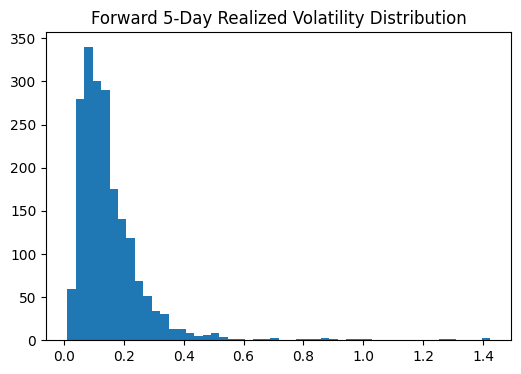

In [19]:
plt.figure(figsize=(6,4))
plt.hist(spy["fwd_rv_5"], bins=50)
plt.title("Forward 5-Day Realized Volatility Distribution")
plt.show()

Basline Model Training

In [7]:
from src.pipeline.train import SplitSpec, train_baselines_3way

split = SplitSpec(
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
)

res = train_baselines_3way(df=feat, target="regime", split=split)

print("=== Split ===")
print(res["split"])
print("\n#features:", len(res["features"]))

for model_name, m in res["models"].items():
    print(f"\n=== {model_name} ===")
    print("VAL  | acc:", round(m["val"]["accuracy"], 4), "macro_f1:", round(m["val"]["macro_f1"], 4))
    print("TEST | acc:", round(m["test"]["accuracy"], 4), "macro_f1:", round(m["test"]["macro_f1"], 4))
    print("VAL confusion:", m["val"]["confusion_matrix"])
    print("TEST confusion:", m["test"]["confusion_matrix"])

=== Split ===
{'train': {'start': '2018-03-29', 'end': '2022-12-30', 'n': 3597}, 'val': {'start': '2023-01-03', 'end': '2023-12-29', 'n': 750}, 'test': {'start': '2024-01-02', 'end': '2026-02-06', 'n': 1581}}

#features: 26

=== logreg ===
VAL  | acc: 0.5307 macro_f1: 0.4301
TEST | acc: 0.5142 macro_f1: 0.4659
VAL confusion: [[195, 112, 6], [133, 193, 44], [15, 42, 10]]
TEST confusion: [[457, 263, 9], [244, 292, 32], [57, 163, 64]]

=== random_forest ===
VAL  | acc: 0.52 macro_f1: 0.4305
TEST | acc: 0.5168 macro_f1: 0.459
VAL confusion: [[229, 76, 8], [184, 148, 38], [20, 34, 13]]
TEST confusion: [[471, 227, 31], [230, 284, 54], [70, 152, 62]]


Random Forest Tuning

In [8]:
from src.pipeline.train import SplitSpec, tune_random_forest

split = SplitSpec(
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
)

tuning_df, best_params = tune_random_forest(df=feat, target="regime", split=split)

print("Best params:", best_params)
tuning_df.head(15)

Best params: {'n_estimators': 400, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced_subsample', 'max_depth': nan, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


,val_macro_f1,val_accuracy,max_depth,min_samples_leaf,max_features
0,0.430543,0.520000,NaN,1,sqrt
1,0.417540,0.526667,NaN,1,0.5
2,0.394596,0.516000,NaN,1,None
3,0.392378,0.520000,8.0,20,None
4,0.392043,0.517333,5.0,5,sqrt
5,0.390881,0.521333,NaN,5,sqrt
6,0.389403,0.516000,NaN,20,None
7,0.389098,0.526667,8.0,5,sqrt
8,0.388857,0.526667,8.0,1,sqrt
9,0.388258,0.514667,NaN,5,0.5


Feature upgrade: add lagged return and lagged VIX-return features

In [9]:
# Rebuild features/labels with new lag features
from src.pipeline.features import build_features_and_labels
from src.pipeline.train import SplitSpec, train_baselines_3way

# Re-run feature construction
feat = build_features_and_labels(
    merged_df=df,
    horizon_days=HORIZON_DAYS,
    train_end=TRAIN_END,
    n_regimes=N_REGIMES,
)

# Save (optional but recommended)
FEATURES_PATH = PROCESSED_DIR / "vol_features_5d_lags.parquet"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
feat.to_parquet(FEATURES_PATH, index=False)

print("Saved:", FEATURES_PATH)
print("New shape:", feat.shape)

# Train/val/test evaluation (same split as before)
split = SplitSpec(
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
)

res = train_baselines_3way(df=feat, target="regime", split=split)

print("=== Split ===")
print(res["split"])
print("\n#features:", len(res["features"]))

for model_name, m in res["models"].items():
    print(f"\n=== {model_name} ===")
    print("VAL  | acc:", round(m["val"]["accuracy"], 4), "macro_f1:", round(m["val"]["macro_f1"], 4))
    print("TEST | acc:", round(m["test"]["accuracy"], 4), "macro_f1:", round(m["test"]["macro_f1"], 4))

Saved: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling/data/processed/vol_features_5d_lags.parquet
New shape: (5928, 30)
=== Split ===
{'train': {'start': '2018-03-29', 'end': '2022-12-30', 'n': 3597}, 'val': {'start': '2023-01-03', 'end': '2023-12-29', 'n': 750}, 'test': {'start': '2024-01-02', 'end': '2026-02-06', 'n': 1581}}

#features: 26

=== logreg ===
VAL  | acc: 0.5307 macro_f1: 0.4301
TEST | acc: 0.5142 macro_f1: 0.4659

=== random_forest ===
VAL  | acc: 0.52 macro_f1: 0.4305
TEST | acc: 0.5168 macro_f1: 0.459


Logistic Regression Tuning

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.pipeline.train import SplitSpec, time_split_3way, select_numeric_features, _make_preprocessor

split = SplitSpec(
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
)

# Split
train_df, val_df, test_df = time_split_3way(feat, split)

# Features (same selection logic as your pipeline)
features = select_numeric_features(feat, target="regime")

X_train, y_train = train_df[features], train_df["regime"].astype(int)
X_val, y_val = val_df[features], val_df["regime"].astype(int)
X_test, y_test = test_df[features], test_df["regime"].astype(int)

preprocessor = _make_preprocessor(features)

grid_C = [0.01, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0]
grid_cw = [None, "balanced"]

rows = []
best = None
best_score = -1

for C in grid_C:
    for cw in grid_cw:
        model = Pipeline([
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=4000, C=C, class_weight=cw)),
        ])

        model.fit(X_train, y_train)
        pred_val = model.predict(X_val)

        val_f1 = float(f1_score(y_val, pred_val, average="macro"))
        val_acc = float(accuracy_score(y_val, pred_val))

        rows.append({
            "C": C,
            "class_weight": cw,
            "val_macro_f1": val_f1,
            "val_accuracy": val_acc,
        })

        if val_f1 > best_score:
            best_score = val_f1
            best = (C, cw)

tune_df = pd.DataFrame(rows).sort_values(["val_macro_f1", "val_accuracy"], ascending=False).reset_index(drop=True)
display(tune_df.head(15))

best_C, best_cw = best
print("Best (by VAL macro-F1):", {"C": best_C, "class_weight": best_cw, "val_macro_f1": best_score})

# Final: retrain on train+val, test once
trainval = pd.concat([train_df, val_df], ignore_index=True)
X_trainval, y_trainval = trainval[features], trainval["regime"].astype(int)

final_model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=4000, C=best_C, class_weight=best_cw)),
])
final_model.fit(X_trainval, y_trainval)

pred_test = final_model.predict(X_test)
test_f1 = float(f1_score(y_test, pred_test, average="macro"))
test_acc = float(accuracy_score(y_test, pred_test))

print("Final TEST:", {"accuracy": round(test_acc, 4), "macro_f1": round(test_f1, 4)})

,C,class_weight,val_macro_f1,val_accuracy
0,1.00,NaN,0.430116,0.530667
1,1.00,balanced,0.430116,0.530667
2,10.00,NaN,0.422262,0.510667
3,10.00,balanced,0.422262,0.510667
4,100.00,NaN,0.419489,0.510667
5,100.00,balanced,0.419489,0.510667
6,3.00,NaN,0.419350,0.513333
7,3.00,balanced,0.419350,0.513333
8,30.00,NaN,0.413753,0.501333
9,30.00,balanced,0.413753,0.501333


Best (by VAL macro-F1): {'C': 1.0, 'class_weight': None, 'val_macro_f1': 0.4301155879726688}
Final TEST: {'accuracy': 0.5123, 'macro_f1': 0.4504}


Gradient Boosting

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline

from src.pipeline.train import SplitSpec, time_split_3way, select_numeric_features, _make_preprocessor

# Same split as before
split = SplitSpec(
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
)

train_df, val_df, test_df = time_split_3way(feat, split)

features = select_numeric_features(feat, target="regime")

X_train, y_train = train_df[features], train_df["regime"].astype(int)
X_val, y_val = val_df[features], val_df["regime"].astype(int)
X_test, y_test = test_df[features], test_df["regime"].astype(int)

preprocessor = _make_preprocessor(features)

# Simple, reasonable starting configuration
gb_model = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=None,
        random_state=42
    )),
])

# Train on TRAIN only
gb_model.fit(X_train, y_train)

# Validation evaluation
val_pred = gb_model.predict(X_val)
val_f1 = f1_score(y_val, val_pred, average="macro")
val_acc = accuracy_score(y_val, val_pred)

print("Gradient Boosting — VAL")
print("Accuracy:", round(val_acc, 4))
print("Macro F1:", round(val_f1, 4))

Gradient Boosting — VAL
Accuracy: 0.5107
Macro F1: 0.4194


Baseline Supervised Models (LogReg, RF)

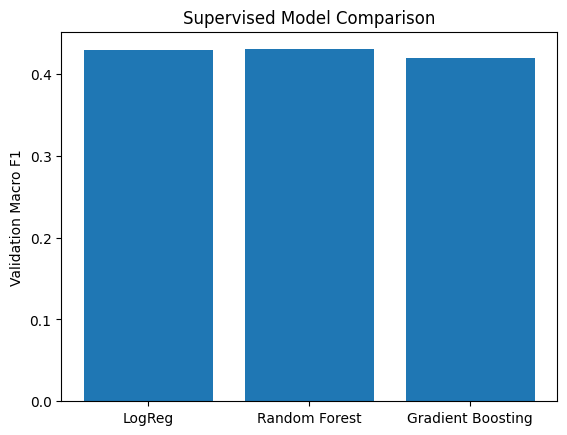

In [21]:
models = ["LogReg", "Random Forest", "Gradient Boosting"]
val_scores = [0.429, 0.430, 0.419]  # replace with actual vals

plt.bar(models, val_scores)
plt.ylabel("Validation Macro F1")
plt.title("Supervised Model Comparison")
plt.show()

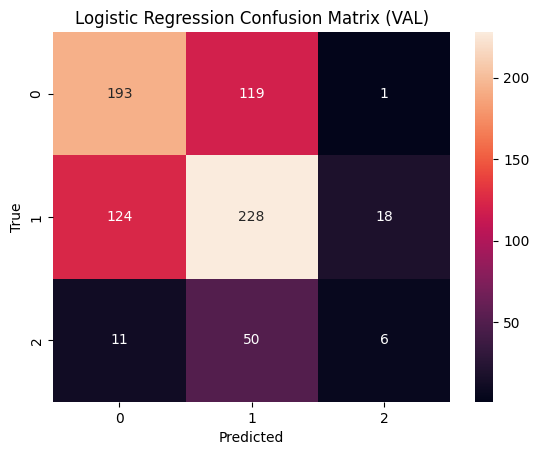

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, final_model.predict(X_val))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix (VAL)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Feature Ablation Visual

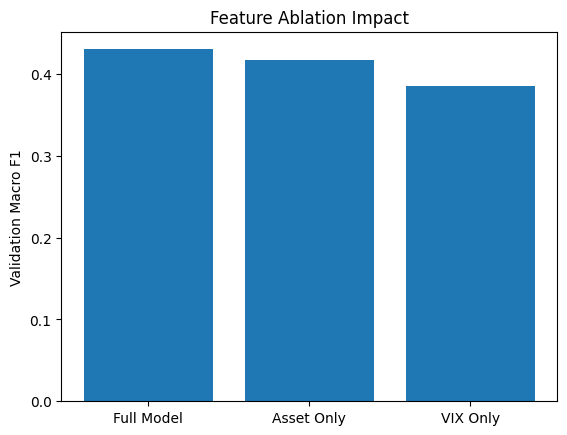

In [24]:
groups = ["Full Model", "Asset Only", "VIX Only"]
scores = [0.430, 0.417, 0.385]  # validation F1s

plt.bar(groups, scores)
plt.ylabel("Validation Macro F1")
plt.title("Feature Ablation Impact")
plt.show()

## Unsupervised regime discovery with a Hidden Markov Model (HMM)

We now model volatility regimes as *latent states* rather than quantile-based labels.
An HMM assumes the market transitions between a small number of hidden regimes over time, and each regime generates
observable market behavior (returns, realized volatility, and VIX dynamics).

Steps:
1. Build an observation matrix from SPY features (returns, rolling volatility, VIX).
2. Fit a 3-state Gaussian HMM on the training period.
3. Decode the most likely hidden state sequence over train/val/test.
4. Compare hidden states to our supervised quantile regimes (alignment + transition behavior).

In [12]:
# If this fails due to environment restrictions, tell me the error text.
!pip -q install hmmlearn

In [13]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# Pick which ticker to model with HMM
TICKER_FOR_HMM = "SPY"

# Observation columns: keep small + interpretable
OBS_COLS = ["log_return", "rv_10", "vix_close"]  # you can swap rv_20 etc if you want

hmm_df = feat[feat["ticker"] == TICKER_FOR_HMM].copy()
hmm_df = hmm_df.sort_values("date").reset_index(drop=True)

# Ensure required cols exist
missing = [c for c in OBS_COLS if c not in hmm_df.columns]
print("Missing observation cols:", missing)

# Drop rows with NA in obs cols (HMM needs dense sequence)
hmm_df = hmm_df.dropna(subset=OBS_COLS).reset_index(drop=True)

print("HMM rows:", len(hmm_df))
print("Date range:", hmm_df["date"].min().date(), "→", hmm_df["date"].max().date())

# Time splits (same as supervised)
train_end_dt = pd.to_datetime(TRAIN_END)
val_start_dt = pd.to_datetime(VAL_START)
val_end_dt   = pd.to_datetime(VAL_END)
test_start_dt = pd.to_datetime(TEST_START)

train_mask = hmm_df["date"] <= train_end_dt
val_mask = (hmm_df["date"] >= val_start_dt) & (hmm_df["date"] <= val_end_dt)
test_mask = hmm_df["date"] >= test_start_dt

print("Train/Val/Test sizes:", train_mask.sum(), val_mask.sum(), test_mask.sum())

X = hmm_df[OBS_COLS].values

# Standardize using TRAIN only (leakage-safe)
scaler = StandardScaler()
X_train = scaler.fit_transform(X[train_mask])
X_all = scaler.transform(X)

Missing observation cols: []
HMM rows: 1976
Date range: 2018-03-29 → 2026-02-06
Train/Val/Test sizes: 1199 250 527


In [14]:
from hmmlearn.hmm import GaussianHMM

N_STATES = 3

hmm = GaussianHMM(
    n_components=N_STATES,
    covariance_type="full",
    n_iter=500,
    random_state=42,
)

hmm.fit(X_train)

# Decode most likely hidden state sequence for the full period
hidden_states = hmm.predict(X_all)

hmm_df["hmm_state"] = hidden_states.astype(int)

print("Transition matrix (rows=from, cols=to):")
print(np.round(hmm.transmat_, 3))

print("\nState means (in standardized space) for obs cols", OBS_COLS)
print(np.round(hmm.means_, 3))

Transition matrix (rows=from, cols=to):
[[0.962 0.019 0.019]
 [0.058 0.942 0.   ]
 [0.024 0.    0.976]]

State means (in standardized space) for obs cols ['log_return', 'rv_10', 'vix_close']
[[-0.007  0.046  0.095]
 [-0.067  1.479  1.599]
 [ 0.037 -0.677 -0.788]]


In [15]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# If regime exists for SPY rows, compare
if "regime" in hmm_df.columns:
    # Remove NA regime rows (if any)
    tmp = hmm_df.dropna(subset=["regime"]).copy()
    y_regime = tmp["regime"].astype(int).values
    y_state = tmp["hmm_state"].astype(int).values

    ari = adjusted_rand_score(y_regime, y_state)
    nmi = normalized_mutual_info_score(y_regime, y_state)

    print("ARI (state vs regime):", round(ari, 4))
    print("NMI (state vs regime):", round(nmi, 4))

    # Cross-tab to see how states map to regimes
    display(pd.crosstab(tmp["hmm_state"], tmp["regime"], normalize="index"))
else:
    print("No 'regime' column found in hmm_df; skipping comparison.")

ARI (state vs regime): 0.2105
NMI (state vs regime): 0.1893


regime,0,1,2
hmm_state,,,
0,0.406250,0.467548,0.126202
1,0.072165,0.329897,0.597938
2,0.805263,0.178947,0.015789


In [16]:
import itertools
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# Extract only rows with regime label
tmp = hmm_df.dropna(subset=["regime"]).copy()
y_true = tmp["regime"].astype(int).values
y_state = tmp["hmm_state"].astype(int).values

best_f1 = -1
best_mapping = None
best_acc = None

for perm in itertools.permutations([0,1,2]):
    mapping = {0: perm[0], 1: perm[1], 2: perm[2]}
    y_pred = np.array([mapping[s] for s in y_state])

    f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_mapping = mapping
        best_acc = acc

print("Best mapping:", best_mapping)
print("Macro F1:", round(best_f1, 4))
print("Accuracy:", round(best_acc, 4))

Best mapping: {0: 1, 1: 2, 2: 0}
Macro F1: 0.6048
Accuracy: 0.6427


HMM State Over Time

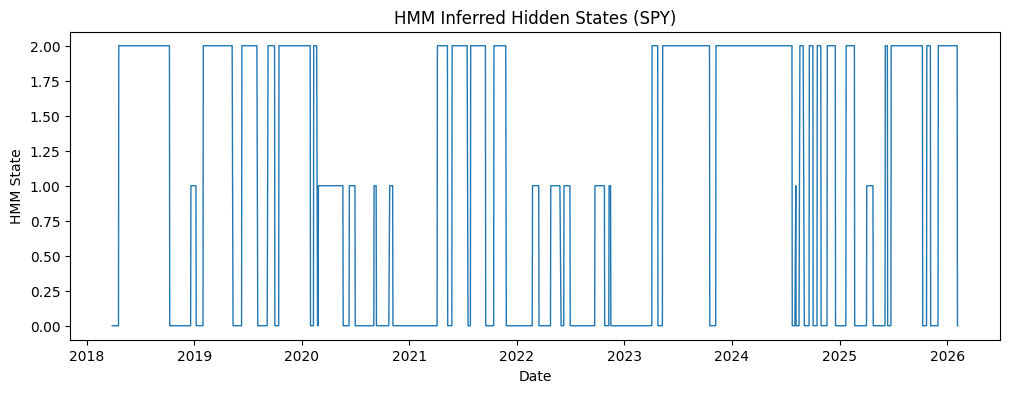

In [25]:
plt.figure(figsize=(12,4))
plt.plot(hmm_df["date"], hmm_df["hmm_state"], linewidth=1)
plt.title("HMM Inferred Hidden States (SPY)")
plt.ylabel("HMM State")
plt.xlabel("Date")
plt.show()

Overlay HMM States With VIX

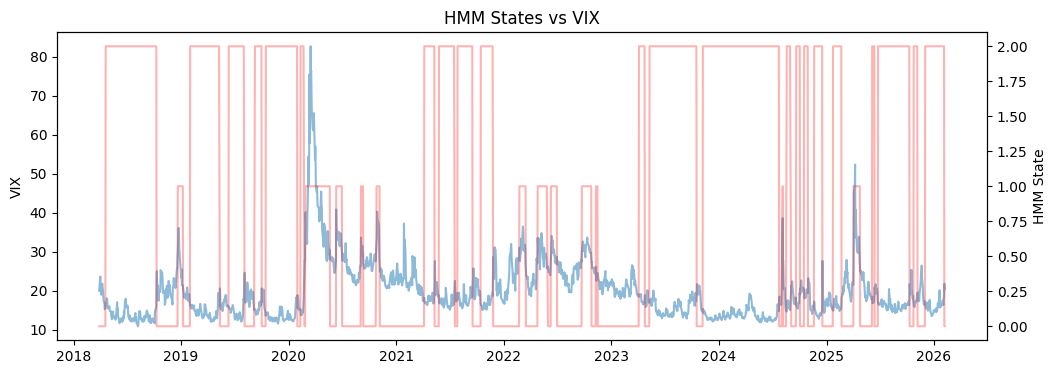

In [26]:
fig, ax1 = plt.subplots(figsize=(12,4))

ax1.plot(hmm_df["date"], hmm_df["vix_close"], alpha=0.5)
ax1.set_ylabel("VIX")

ax2 = ax1.twinx()
ax2.plot(hmm_df["date"], hmm_df["hmm_state"], color="red", alpha=0.3)
ax2.set_ylabel("HMM State")

plt.title("HMM States vs VIX")
plt.show()

Transition Matrix Heatmaps

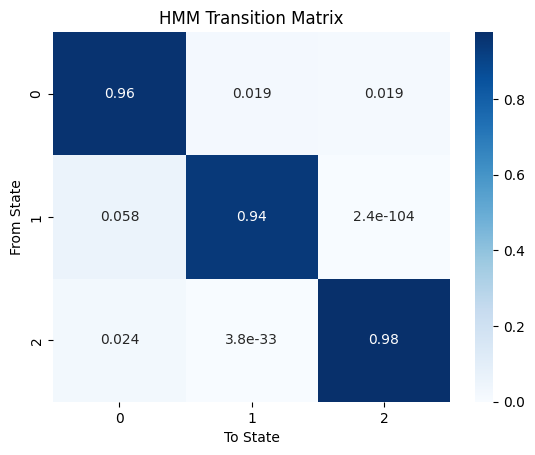

In [27]:
sns.heatmap(hmm.transmat_, annot=True, cmap="Blues")
plt.title("HMM Transition Matrix")
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()

HMM vs Supervised Regime Alignment

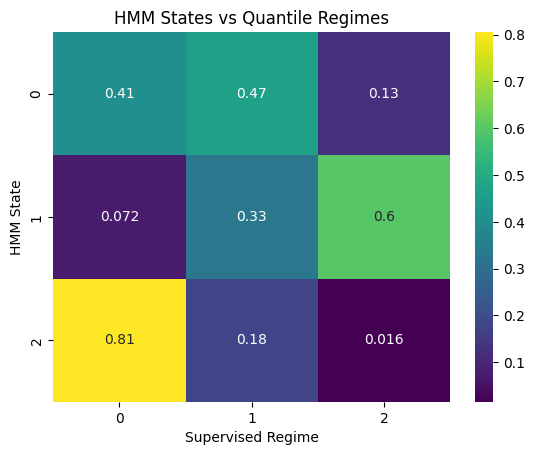

In [28]:
ct = pd.crosstab(tmp["hmm_state"], tmp["regime"], normalize="index")
sns.heatmap(ct, annot=True, cmap="viridis")
plt.title("HMM States vs Quantile Regimes")
plt.xlabel("Supervised Regime")
plt.ylabel("HMM State")
plt.show()

## K-Means Unsupervised Regime Discovery

We now apply K-Means clustering as a second unsupervised approach using the same SPY observation
features as HMM (`log_return`, `rv_10`, `vix_close`). Unlike HMM, K-Means does not model
temporal dynamics — it groups observations purely by feature similarity in standardized space.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ── data prep (self-contained, safe to run without HMM cells) ──────────────
TICKER_FOR_HMM = "SPY"
OBS_COLS       = ["log_return", "rv_10", "vix_close"]
N_STATES       = 3
TRAIN_END      = "2022-12-30"

km_df = feat[feat["ticker"] == TICKER_FOR_HMM].copy()
km_df = km_df.sort_values("date").reset_index(drop=True)
km_df = km_df.dropna(subset=OBS_COLS).reset_index(drop=True)

train_mask = km_df["date"] <= pd.to_datetime(TRAIN_END)
X          = km_df[OBS_COLS].values
scaler_km  = StandardScaler().fit(X[train_mask])
X_train_km = scaler_km.transform(X[train_mask])
X_all_km   = scaler_km.transform(X)

# ── fit K-Means ─────────────────────────────────────────────────────────────
km = KMeans(n_clusters=N_STATES, random_state=42, n_init=10)
km.fit(X_train_km)
km_df["km_state"] = km.predict(X_all_km).astype(int)

# merge hmm_state if HMM cells have already been run
try:
    km_df = km_df.merge(hmm_df[["date", "hmm_state"]], on="date", how="left")
except Exception:
    pass

tmp_km = km_df.dropna(subset=["regime"]).copy()

# order clusters by mean rv_10 (0=low vol, 1=mid, 2=high vol)
cluster_rv = tmp_km.groupby("km_state")["rv_10"].mean().sort_values()
km_order   = {old: new for new, old in enumerate(cluster_rv.index)}
tmp_km["km_state"] = tmp_km["km_state"].map(km_order)
km_df["km_state"]  = km_df["km_state"].map(km_order)

km_centers = pd.DataFrame(
    km.cluster_centers_[list(cluster_rv.index)],
    columns=OBS_COLS,
    index=["Low Vol", "Mid Vol", "High Vol"],
)
km_colors = {0: "green", 1: "orange", 2: "red"}

print("K-Means cluster centers (standardized):")
print(km_centers)

### K-Means Regimes Over Time

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
for state in range(N_STATES):
    mask = tmp_km["km_state"] == state
    ax.scatter(tmp_km.loc[mask, "date"], tmp_km.loc[mask, "rv_10"],
               c=km_colors[state], label=f"Cluster {state}", s=8, alpha=0.7)
ax.set_title("K-Means Regimes Over Time (SPY — rv_10 colored by cluster)")
ax.set_xlabel("Date")
ax.set_ylabel("rv_10")
ax.legend()
plt.tight_layout()
plt.show()

### K-Means Cluster Centers

In [ ]:
km_centers.T.plot(kind="bar", figsize=(9, 4))
plt.title("K-Means Cluster Centers (Standardized Features)")
plt.ylabel("Standardized Value")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### K-Means Regimes vs VIX Overlay

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(km_df["date"], km_df["vix_close"], color="gray", lw=0.8, label="VIX")
for state in range(N_STATES):
    mask = km_df["km_state"] == state
    axes[0].scatter(km_df.loc[mask, "date"], km_df.loc[mask, "vix_close"],
                    c=km_colors[state], s=6, alpha=0.6, label=f"Cluster {state}")
axes[0].set_title("K-Means Regimes vs VIX (SPY)")
axes[0].set_ylabel("VIX")
axes[0].legend()

axes[1].plot(km_df["date"], km_df["km_state"], color="steelblue", lw=0.8)
axes[1].set_title("K-Means Cluster Over Time")
axes[1].set_ylabel("Cluster")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## K-Means vs HMM Comparison

We now compare the two unsupervised approaches — K-Means and HMM — against each other and against
the supervised quantile-based regimes. ARI (Adjusted Rand Index) and NMI (Normalized Mutual
Information) measure clustering agreement, where 1.0 = perfect agreement and 0.0 = random.

In [ ]:
ari_km_hmm  = adjusted_rand_score(tmp_km["hmm_state"], tmp_km["km_state"])
nmi_km_hmm  = normalized_mutual_info_score(tmp_km["hmm_state"], tmp_km["km_state"])
ari_hmm_sup = adjusted_rand_score(tmp_km["regime"].astype(int), tmp_km["hmm_state"])
nmi_hmm_sup = normalized_mutual_info_score(tmp_km["regime"].astype(int), tmp_km["hmm_state"])
ari_km_sup  = adjusted_rand_score(tmp_km["regime"].astype(int), tmp_km["km_state"])
nmi_km_sup  = normalized_mutual_info_score(tmp_km["regime"].astype(int), tmp_km["km_state"])

print(f"K-Means vs HMM          — ARI: {ari_km_hmm:.4f},  NMI: {nmi_km_hmm:.4f}")
print(f"HMM vs Quantile Regimes — ARI: {ari_hmm_sup:.4f}, NMI: {nmi_hmm_sup:.4f}")
print(f"K-Means vs Quantile     — ARI: {ari_km_sup:.4f},  NMI: {nmi_km_sup:.4f}")

summary = pd.DataFrame({
    "ARI vs Quantile Regimes": [ari_hmm_sup, ari_km_sup],
    "NMI vs Quantile Regimes": [nmi_hmm_sup, nmi_km_sup],
    "ARI vs Each Other": [ari_km_hmm, ari_km_hmm],
}, index=["HMM", "K-Means"])
display(summary)

### K-Means vs HMM Cross-Tab

In [ ]:
ct_km_hmm = pd.crosstab(tmp_km["km_state"], tmp_km["hmm_state"], normalize="index")
ct_km_hmm.index = [f"KM Cluster {i}" for i in ct_km_hmm.index]
ct_km_hmm.columns = [f"HMM State {c}" for c in ct_km_hmm.columns]

plt.figure(figsize=(7, 4))
sns.heatmap(ct_km_hmm, annot=True, fmt=".2f", cmap="Blues")
plt.title("K-Means vs HMM States (row-normalized)")
plt.xlabel("HMM State")
plt.ylabel("K-Means Cluster")
plt.tight_layout()
plt.show()

### Side-by-Side Regime Timeline: K-Means vs HMM

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(km_df["date"], km_df["hmm_state"], lw=0.8, color="steelblue")
axes[0].set_title("HMM States Over Time (SPY)")
axes[0].set_ylabel("State")

axes[1].plot(km_df["date"], km_df["km_state"], lw=0.8, color="darkorange")
axes[1].set_title("K-Means Clusters Over Time (SPY)")
axes[1].set_ylabel("Cluster")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### ARI / NMI Comparison: HMM vs K-Means

In [ ]:
comparison = pd.DataFrame({
    "ARI vs Quantile Regimes": [ari_hmm_sup, ari_km_sup],
    "NMI vs Quantile Regimes": [nmi_hmm_sup, nmi_km_sup],
}, index=["HMM", "K-Means"])

comparison.plot(kind="bar", figsize=(7, 4), rot=0)
plt.title("HMM vs K-Means: Agreement with Supervised Quantile Regimes")
plt.ylabel("Score")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

END OF DOCUMENT

In [2]:
print("hello world")

hello world
